In [1]:
import os
import torch
import numpy as np
from tqdm import tqdm
import pandas as pd

from utils.dataclass import TimeSeriesInferenceDataset
from utils.load_and_clean_real_data import load_and_clean_real_data

from utils.mcmc import logprior, loglike_alpha_mu_omega, next_MCMC_sample


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
np.random.seed(42)


In [3]:
grid_estimation = torch.tensor((0.04,1.25,0.615)).to(device)
#grid_estimation = torch.tensor((0.04,.8,0.6)).to(device)
jumpsize_proposal = torch.tensor((1e-2,1e-2,1e-2)).to(device)


In [4]:
real_data_path = "real_data/Exp_1_live_lowpH.csv"

filename = os.path.basename(real_data_path)  # Exp_1_live_lowpH.csv
mcmc_output_path = os.path.join("mcmc_results", filename)

os.makedirs("mcmc_results", exist_ok=True)


In [5]:
df = load_and_clean_real_data(real_data_path, cutoff=300)
ts     = torch.tensor(df["Day"].values * 24)
counts = torch.tensor(df["Counts"].values)
dils   = torch.tensor(df["Dilution"].values)

kappa_np = np.load("kappa_samples_stratified.npz")["kappa_samples"]
kappa_np.sort()
print((kappa_np>1000).mean())
kappa_np = kappa_np[kappa_np>1000]
kappa_np = kappa_np[np.arange(len(kappa_np)) % 32 == 0]  # thin out samples for faster testing

dataset = TimeSeriesInferenceDataset(
    ts=ts, counts=counts, dils=dils,
    kappa_samples=kappa_np,
    cutoff=300,
    t_switch=None,
    rho=1.,
    device=device,
)


[WARN] Missing columns skipped: CFU_2, CFU_2222
[INFO] Using dilutions: [22, 222]
[INFO] Loaded 350 rows from real_data/Exp_1_live_lowpH.csv
[INFO] Retained 349 rows with valid CFU entries.
[INFO] Dropped 1 rows with no valid CFU values at any dilution.
1.0
Dataset loaded: 349 points, 5 timepoints.


In [6]:
N_samples=1000

samples = []
lps = []

logposterior = lambda th: loglike_alpha_mu_omega(dataset, *th) + logprior(*th)

start = grid_estimation.clone()
theta = start
for i in range(4):
    lp = logposterior(theta)
    print(lp)


/home/pessoa/Codes/Celegans_inference/utils/mcmc.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  - torch.lgamma(torch.tensor(k, dtype=x.dtype, device=x.device))


tensor([-1985.7007], device='cuda:0')
tensor([-1984.5741], device='cuda:0')
tensor([-1990.0957], device='cuda:0')
tensor([-1986.2936], device='cuda:0')


In [ ]:
for i in tqdm(range(N_samples)):
    lp = logposterior(theta)
    theta, lp = next_MCMC_sample(logposterior, theta, lp, jumpsize_proposal)
    samples.append(theta.clone().cpu().numpy())
    lps.append(lp.item()*1.)
    

    if (i + 1) % 10 == 0:
        samples_tensor = np.vstack(samples)

        df = pd.DataFrame({
            "alpha": samples_tensor[:, 0],
            "mu": samples_tensor[:, 1],
            "omega": samples_tensor[:, 2],
            "logposterior": np.array(lps)
        })

        #df.to_csv(mcmc_output_path)

        #print(f"Saved at iteration {i+1}")
        print (theta,lp.item())


  1%|          | 10/1000 [03:16<5:23:51, 19.63s/it]

tensor([0.0399, 1.2330, 0.6329], device='cuda:0') -1979.95849609375


  2%|▏         | 20/1000 [06:33<5:23:24, 19.80s/it]

tensor([0.0399, 1.2106, 0.6341], device='cuda:0') -1976.669677734375


  3%|▎         | 30/1000 [09:57<5:44:01, 21.28s/it]

...

 55%|█████▌    | 550/1000 [3:08:16<2:08:12, 17.10s/it]

tensor([0.0358, 0.9457, 0.5713], device='cuda:0') -1972.6749267578125


 56%|█████▌    | 560/1000 [3:11:26<2:21:34, 19.31s/it]

tensor([0.0359, 0.9335, 0.5712], device='cuda:0') -1970.53564453125


 57%|█████▋    | 569/1000 [3:14:23<2:19:32, 19.43s/it]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def basic_corner(samples_tensor, labels=None, bins=30):
    """
    Very basic corner plot using matplotlib only.
    
    samples_tensor: torch.Tensor or np.ndarray of shape (N, D)
    labels: list of length D
    """
    # convert to numpy if torch
    if hasattr(samples_tensor, "detach"):
        samples = samples_tensor.detach().cpu().numpy()
    else:
        samples = np.asarray(samples_tensor)

    N, D = samples.shape

    fig, axes = plt.subplots(D, D, figsize=(2.5*D, 2.5*D))

    for i in range(D):
        for j in range(D):

            ax = axes[i, j]

            # Upper triangle → remove
            if j > i:
                ax.axis("off")
                continue

            # Diagonal → histogram
            if i == j:
                ax.hist(samples[:, i], bins=bins)
            else:
                ax.scatter(samples[:, j], samples[:, i], s=5, alpha=0.3)

            # Labels
            if i == D - 1:
                ax.set_xlabel(labels[j] if labels else f"$\\theta_{j}$")
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(labels[i] if labels else f"$\\theta_{i}$")
            else:
                ax.set_yticklabels([])

    plt.tight_layout()
    return fig


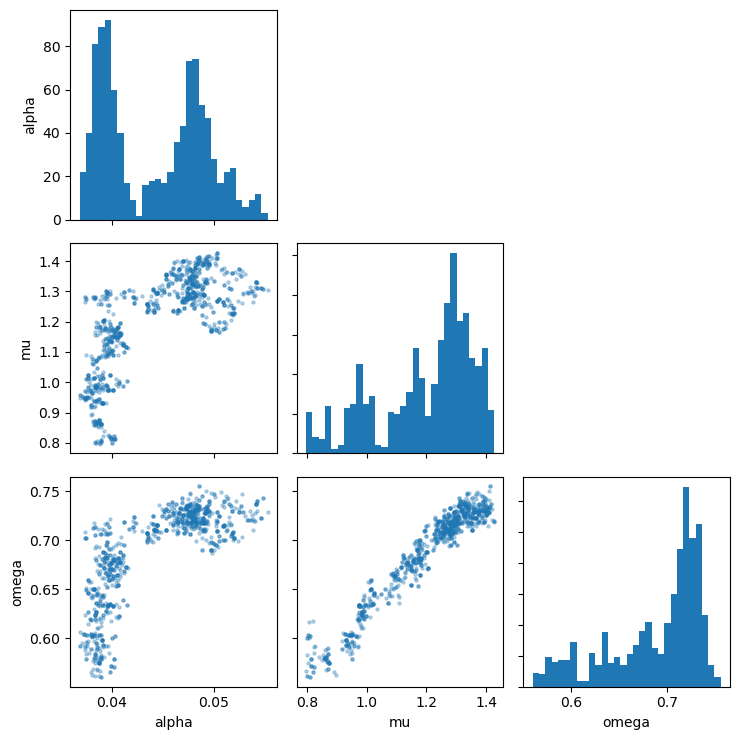

In [ ]:
basic_corner(samples_tensor, labels=["alpha", "mu", "omega"])
plt.show()


Text(0.5, 1.0, 'Trace plot for alpha')

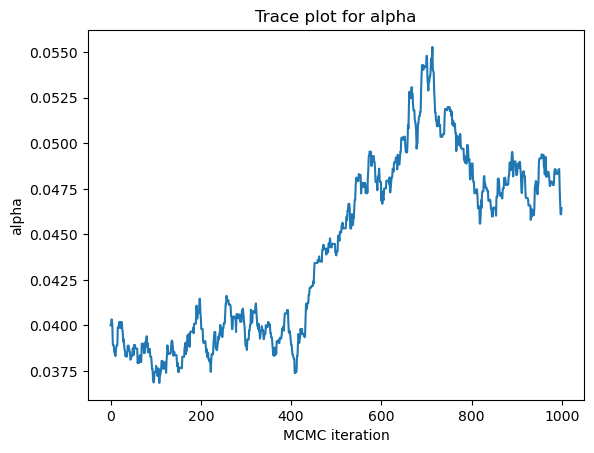

In [ ]:
plt.plot(samples_tensor[:, 0])
plt.xlabel("MCMC iteration")
plt.ylabel("alpha")
plt.title("Trace plot for alpha")


Text(0.5, 1.0, 'Trace plot for mu')

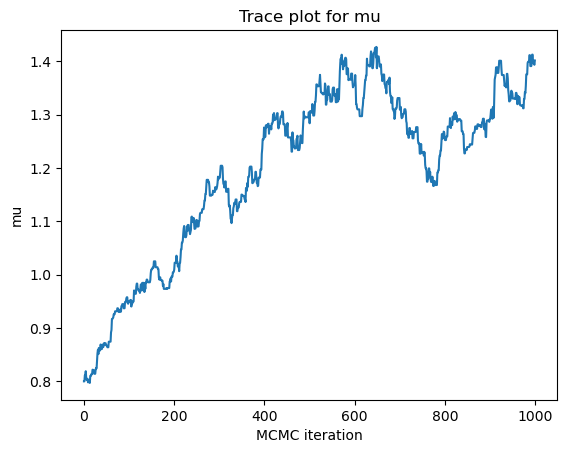

In [ ]:
plt.plot(samples_tensor[:, 1])
plt.xlabel("MCMC iteration")
plt.ylabel("mu")
plt.title("Trace plot for mu")


Text(0.5, 1.0, 'Trace plot for omega')

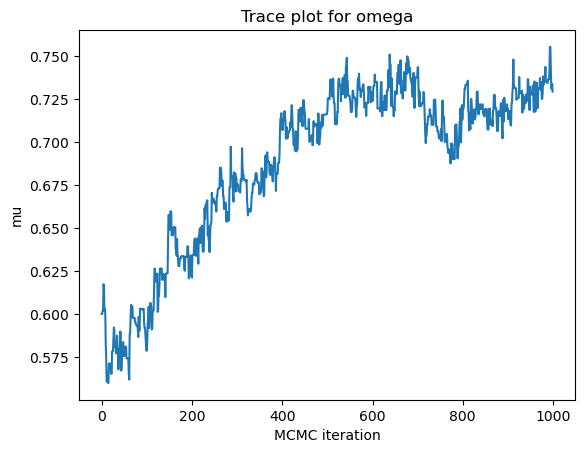

In [ ]:
plt.plot(samples_tensor[:, 2])
plt.xlabel("MCMC iteration")
plt.ylabel("mu")
plt.title("Trace plot for omega")


Text(0.5, 0, 'log10(capacity)')

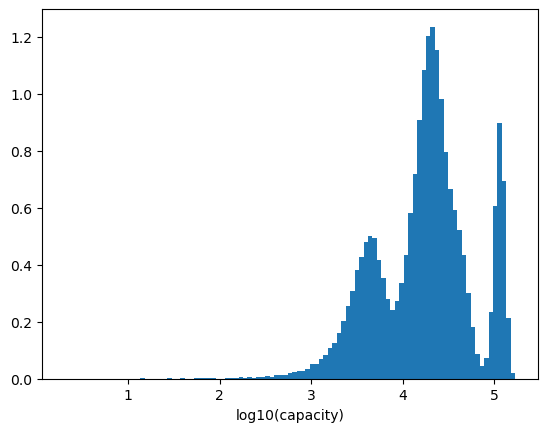

In [ ]:
plt.hist(np.log10(np.load("kappa_samples_Exp1_4gauss.npz")["kappa_samples"]),bins=101,density=True)
plt.xlabel("log10(capacity)")


In [ ]:
8150-444.44-333.33-444.44-1998.78


4929.010000000001

In [ ]:
8150.71-528.62-492.49-1998.78-528.27


4602.550000000001

In [ ]:
plt.plot(lps)
plt.ylim(max(lps)-20, max(lps)+1)


NameError: name 'lps' is not defined